<a href="https://colab.research.google.com/github/sankalp120/machinelearning/blob/main/Copy_of_EuroSat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
apollo2506_eurosat_dataset_path = kagglehub.dataset_download('apollo2506/eurosat-dataset')

print('Data source import complete.')


Using Colab cache for faster access to the 'eurosat-dataset' dataset.
Data source import complete.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Streaming output truncated to the last 5000 lines.
/kaggle/input/eurosat-dataset/EuroSAT/Forest/Forest_927.jpg
/kaggle/input/eurosat-dataset/EuroSAT/Forest/Forest_1248.jpg
/kaggle/input/eurosat-dataset/EuroSAT/Forest/Forest_1042.jpg
/kaggle/input/eurosat-dataset/EuroSAT/Forest/Forest_98.jpg
/kaggle/input/eurosat-dataset/EuroSAT/Forest/Forest_548.jpg
/kaggle/input/eurosat-dataset/EuroSAT/Forest/Forest_1262.jpg
/kaggle/input/eurosat-dataset/EuroSAT/Forest/Forest_695.jpg
/kaggle/input/eurosat-dataset/EuroSAT/Forest/Forest_538.jpg
/kaggle/input/eurosat-dataset/EuroSAT/Forest/Forest_1386.jpg
/kaggle/input/eurosat-dataset/EuroSAT/Forest/Forest_1558.jpg
/kaggle/input/eurosat-dataset/EuroSAT/Forest/Forest_1027.jpg
/kaggle/input/eurosat-dataset/EuroSAT/Forest/Forest_2184.jpg
/kaggle/input/eurosat-dataset/EuroSAT/Forest/Forest_2005.jpg
/kaggle/input/eurosat-dataset/EuroSAT/Forest/Forest_2154.jpg
/kaggle/input/eurosat-dataset/EuroSAT/Forest/Forest_1599.jpg
/kaggle/input/eurosat-dataset/EuroSAT/Fo

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [4]:
dataset_path = "/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT"

In [5]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Correcting the dataset_path for the current cell
import os
dataset_path = os.path.join(apollo2506_eurosat_dataset_path, 'EuroSAT')

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.3    #converts pixel values from 0-255 to 0/1
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 18900 images belonging to 10 classes.
Found 8100 images belonging to 10 classes.


In [6]:
images, labels = next(train_data)

In [7]:
from tensorflow.keras import layers, models

model_cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history_cnn = model_cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 162s 264ms/step - accuracy: 0.5083 - loss: 1.2952 - val_accuracy: 0.6896 - val_loss: 0.8747
Epoch 2/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 30s 50ms/step - accuracy: 0.7186 - loss: 0.7762 - val_accuracy: 0.6748 - val_loss: 0.8690
Epoch 3/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - accuracy: 0.7948 - loss: 0.5758 - val_accuracy: 0.8048 - val_loss: 0.5610
Epoch 4/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - accuracy: 0.8473 - loss: 0.4370 - val_accuracy: 0.8302 - val_loss: 0.4896
Epoch 5/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 30s 50ms/step - accuracy: 0.8795 - loss: 0.3408 - val_accuracy: 0.8431 - val_loss: 0.4745
Epoch 6/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step - accuracy: 0.9048 - loss: 0.2715 - val_accuracy: 0.8036 - val_loss: 0.5870
Epoch 7/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - accuracy: 0.9344 - loss: 0.1908 - val_accuracy: 0.8514 - val_loss: 0.4942
Epoch 8/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 30s 50ms/step - accuracy: 0.9481 - loss: 0.1530 

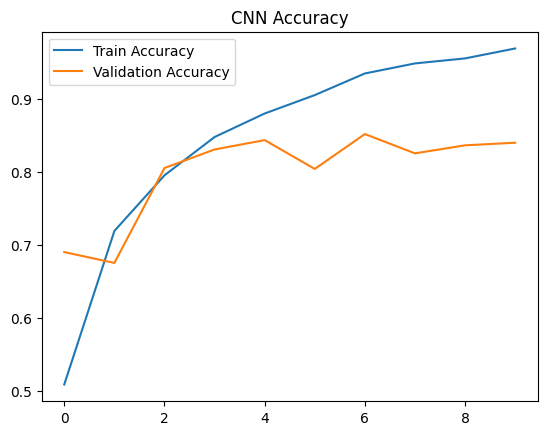

In [9]:
import matplotlib.pyplot as plt

plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("CNN Accuracy")
plt.show()

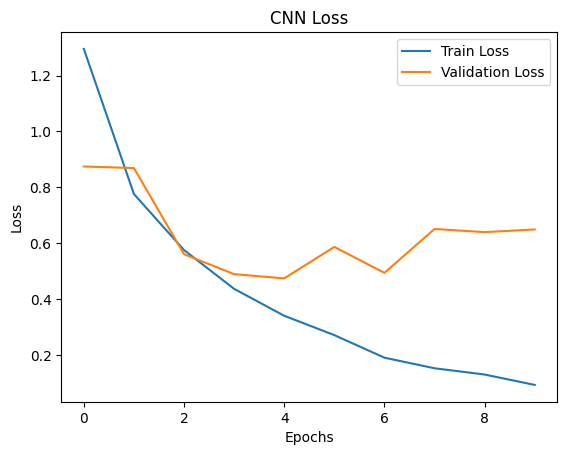

In [10]:
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("CNN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

254/254 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step


<Figure size 1000x1000 with 0 Axes>

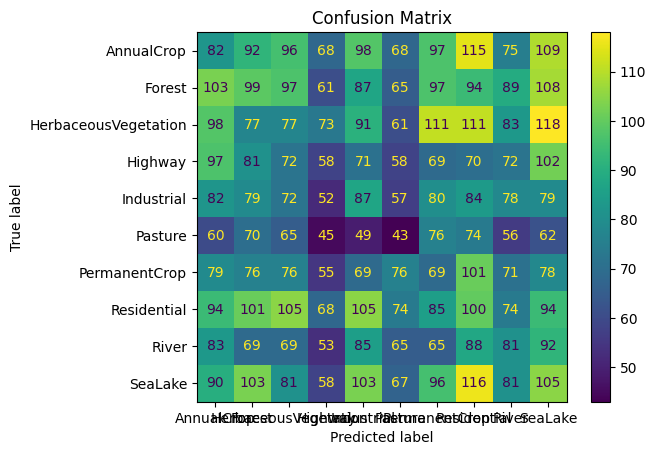

In [11]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions
y_pred = model_cnn.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=list(val_data.class_indices.keys()))
plt.figure(figsize=(10,10))
disp.plot()
plt.title("Confusion Matrix")
plt.show()

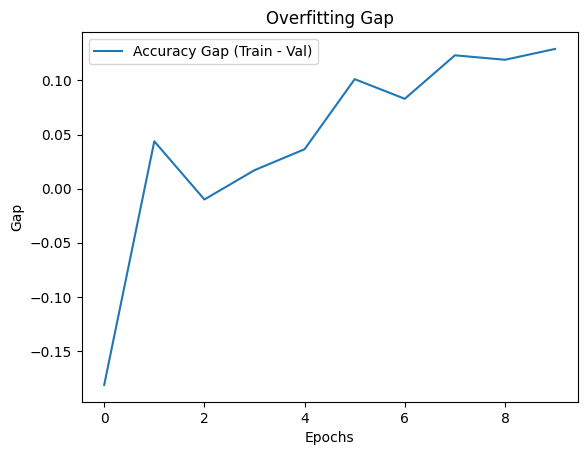

In [12]:
gap = np.array(history_cnn.history['accuracy']) - np.array(history_cnn.history['val_accuracy'])

plt.plot(gap, label='Accuracy Gap (Train - Val)')
plt.title("Overfitting Gap")
plt.xlabel("Epochs")
plt.ylabel("Gap")
plt.legend()
plt.show()

In [13]:
#retraining epoch 6
model_cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
history_cnn = model_cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=6
)

Epoch 1/6
591/591 ━━━━━━━━━━━━━━━━━━━━ 36s 55ms/step - accuracy: 0.4269 - loss: 1.5298 - val_accuracy: 0.6180 - val_loss: 1.0574
Epoch 2/6
591/591 ━━━━━━━━━━━━━━━━━━━━ 30s 50ms/step - accuracy: 0.6245 - loss: 1.0719 - val_accuracy: 0.6995 - val_loss: 0.8423
Epoch 3/6
591/591 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step - accuracy: 0.7081 - loss: 0.8462 - val_accuracy: 0.7351 - val_loss: 0.7294
Epoch 4/6
591/591 ━━━━━━━━━━━━━━━━━━━━ 29s 50ms/step - accuracy: 0.7507 - loss: 0.7135 - val_accuracy: 0.7968 - val_loss: 0.5793
Epoch 5/6
591/591 ━━━━━━━━━━━━━━━━━━━━ 29s 50ms/step - accuracy: 0.7745 - loss: 0.6512 - val_accuracy: 0.8281 - val_loss: 0.5044
Epoch 6/6
591/591 ━━━━━━━━━━━━━━━━━━━━ 30s 50ms/step - accuracy: 0.8072 - loss: 0.5686 - val_accuracy: 0.8386 - val_loss: 0.4669


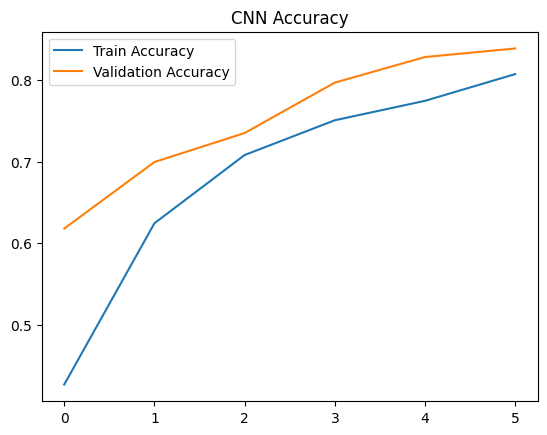

In [15]:
import matplotlib.pyplot as plt

plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("CNN Accuracy")
plt.show()

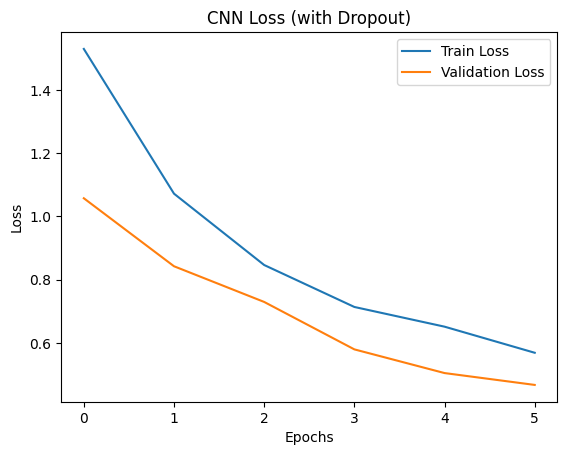

In [16]:
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("CNN Loss (with Dropout)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

254/254 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step


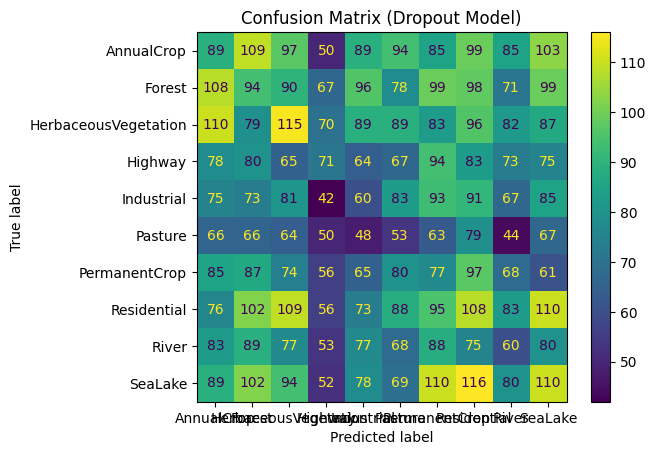

In [17]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


y_pred = model_cnn.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred_classes)

disp = ConfusionMatrixDisplay(cm,
    display_labels=list(val_data.class_indices.keys()))
disp.plot()
plt.title("Confusion Matrix (Dropout Model)")
plt.show()

In [18]:
#retraining epoch 7
model_cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
history_cnn = model_cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=7
)

Epoch 1/7
591/591 ━━━━━━━━━━━━━━━━━━━━ 37s 57ms/step - accuracy: 0.3709 - loss: 1.6260 - val_accuracy: 0.5691 - val_loss: 1.1973
Epoch 2/7
591/591 ━━━━━━━━━━━━━━━━━━━━ 30s 50ms/step - accuracy: 0.5731 - loss: 1.1838 - val_accuracy: 0.6702 - val_loss: 0.9103
Epoch 3/7
591/591 ━━━━━━━━━━━━━━━━━━━━ 29s 50ms/step - accuracy: 0.6649 - loss: 0.9492 - val_accuracy: 0.7300 - val_loss: 0.7645
Epoch 4/7
591/591 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - accuracy: 0.7199 - loss: 0.7915 - val_accuracy: 0.7859 - val_loss: 0.6083
Epoch 5/7
591/591 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step - accuracy: 0.7619 - loss: 0.6827 - val_accuracy: 0.8122 - val_loss: 0.5348
Epoch 6/7
591/591 ━━━━━━━━━━━━━━━━━━━━ 30s 50ms/step - accuracy: 0.7856 - loss: 0.6182 - val_accuracy: 0.8157 - val_loss: 0.5202
Epoch 7/7
591/591 ━━━━━━━━━━━━━━━━━━━━ 29s 50ms/step - accuracy: 0.8128 - loss: 0.5418 - val_accuracy: 0.8328 - val_loss: 0.4759


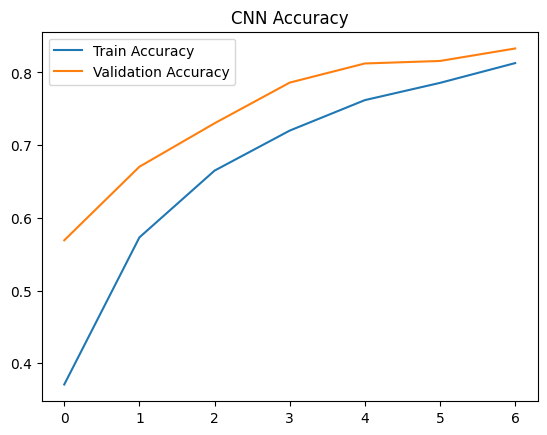

In [20]:
import matplotlib.pyplot as plt

plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("CNN Accuracy")
plt.show()

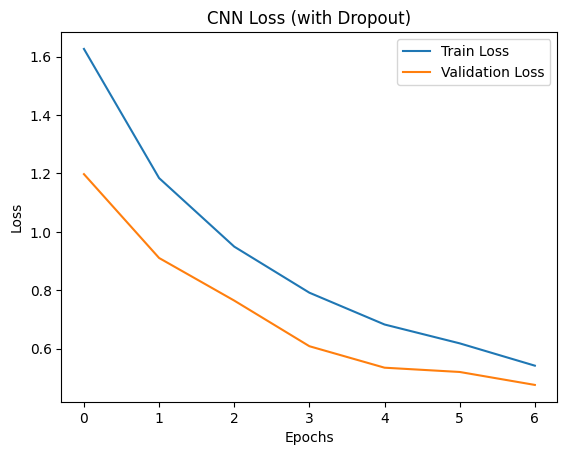

In [21]:
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("CNN Loss (with Dropout)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

254/254 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step


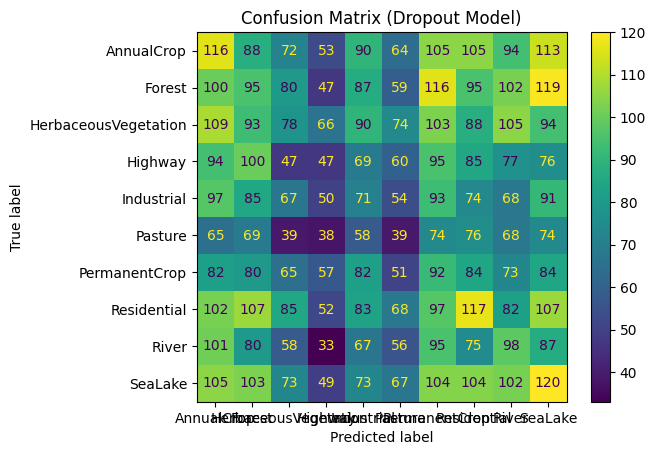

In [22]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


y_pred = model_cnn.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred_classes)

disp = ConfusionMatrixDisplay(cm,
    display_labels=list(val_data.class_indices.keys()))
disp.plot()
plt.title("Confusion Matrix (Dropout Model)")
plt.show()

In [23]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [24]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
predictions = layers.Dense(train_data.num_classes, activation='softmax')(x)

model_tl = models.Model(inputs=base_model.input, outputs=predictions)

model_tl.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_tl.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [25]:
history_tl = model_tl.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 79s 103ms/step - accuracy: 0.7865 - loss: 0.6389 - val_accuracy: 0.8774 - val_loss: 0.3659
Epoch 2/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 31s 52ms/step - accuracy: 0.8595 - loss: 0.4175 - val_accuracy: 0.9015 - val_loss: 0.2800
Epoch 3/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 31s 53ms/step - accuracy: 0.8733 - loss: 0.3695 - val_accuracy: 0.9017 - val_loss: 0.2783
Epoch 4/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 31s 52ms/step - accuracy: 0.8906 - loss: 0.3262 - val_accuracy: 0.9042 - val_loss: 0.2793
Epoch 5/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 32s 53ms/step - accuracy: 0.8969 - loss: 0.3044 - val_accuracy: 0.9080 - val_loss: 0.2684


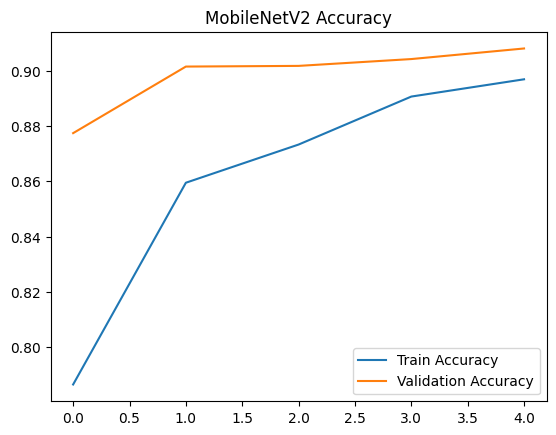

In [26]:
plt.plot(history_tl.history['accuracy'], label='Train Accuracy')
plt.plot(history_tl.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("MobileNetV2 Accuracy")
plt.show()

In [27]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true = val_data.classes
y_pred = model_tl.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_true, y_pred_classes))

254/254 ━━━━━━━━━━━━━━━━━━━━ 19s 57ms/step
              precision    recall  f1-score   support

           0       0.10      0.10      0.10       900
           1       0.11      0.11      0.11       900
           2       0.11      0.11      0.11       900
           3       0.09      0.09      0.09       750
           4       0.09      0.09      0.09       750
           5       0.08      0.08      0.08       600
           6       0.08      0.08      0.08       750
           7       0.11      0.11      0.11       900
           8       0.09      0.08      0.08       750
           9       0.11      0.11      0.11       900

    accuracy                           0.10      8100
   macro avg       0.10      0.10      0.10      8100
weighted avg       0.10      0.10      0.10      8100

